<a href="https://colab.research.google.com/github/Teja3993/Deep-Learning-Lab-exercises/blob/main/Experiment_9_Image_Denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- Training Denoising Autoencoder ---
Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 102s 212ms/step - loss: 0.1825 - val_loss: 0.1259
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 96s 204ms/step - loss: 0.1210 - val_loss: 0.1159
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 98s 210ms/step - loss: 0.1147 - val_loss: 0.1113

--- Generating Predictions for Visualization ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


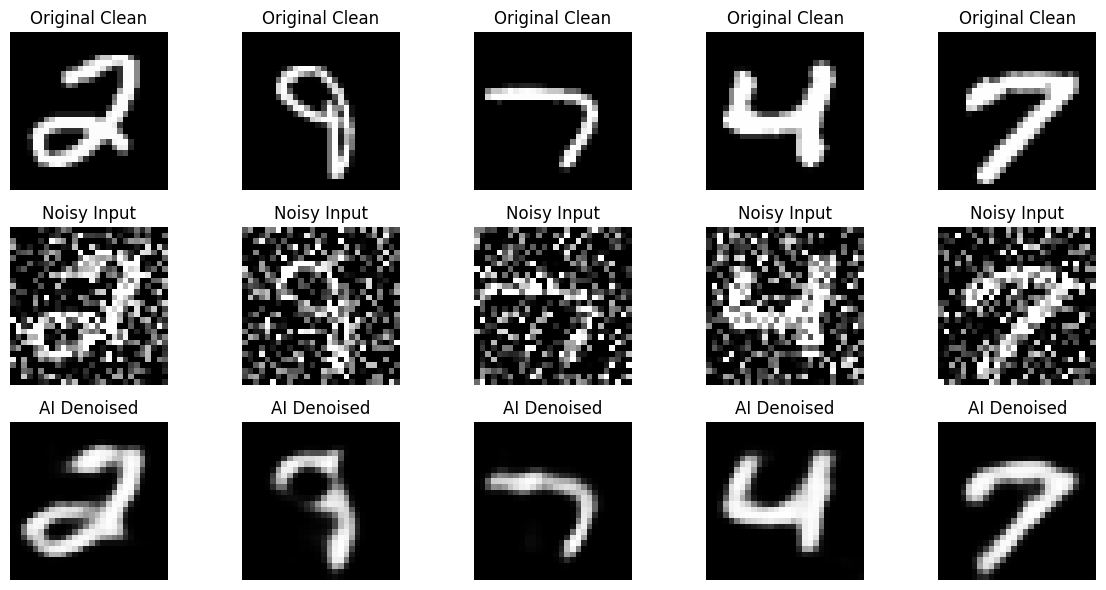

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
import matplotlib.pyplot as plt

# ==========================================
# 1. Load Data (MNIST Digits)
# ==========================================
# We only need the images (X), not the labels (y), because the model learns to output the image itself.
(X_train, _), (X_test, _) = tf.keras.datasets.mnist.load_data()

# Preprocess: Normalize to 0-1 and reshape to add the color channel dimension
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

# ==========================================
# 2. Generate Synthetic Noise
# ==========================================
# We create a noisy version of the dataset to act as the inputs for our model.
noise_factor = 0.5
X_train_noisy = X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_noisy = X_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)

# Ensure pixel values do not exceed 1.0 or drop below 0.0
X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

# ==========================================
# 3. Build the Denoising Autoencoder
# ==========================================
input_img = Input(shape=(28, 28, 1))

# --- ENCODER (Compresses the image) ---
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x) # Bottleneck: Image is now highly compressed

# --- DECODER (Rebuilds the image) ---
x = Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)

# Output Layer: Sigmoid predicts the final pixel intensities (0 to 1)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Combine into a single model
autoencoder = Model(input_img, decoded)

# Compile using Binary Crossentropy because we are predicting pixel values between 0 and 1
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# ==========================================
# 4. Train the Model
# ==========================================
print("--- Training Denoising Autoencoder ---")
# CRITICAL STEP: The input is the NOISY image, but the target is the CLEAN image
autoencoder.fit(X_train_noisy, X_train,
                epochs=3, # Kept low for quick testing, increase to 10+ for perfect results
                batch_size=128,
                shuffle=True,
                validation_data=(X_test_noisy, X_test))

# ==========================================
# 5. Evaluate and Visualize Results
# ==========================================
print("\n--- Generating Predictions for Visualization ---")
# Ask the trained model to clean the unseen noisy test images
decoded_imgs = autoencoder.predict(X_test_noisy)

# Plot 5 random samples to see how well it worked
n = 5
plt.figure(figsize=(12, 6))
indices = np.random.randint(0, len(X_test), n)

for i, idx in enumerate(indices):
    # 1st Row: Original Clean Image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title("Original Clean")
    plt.axis('off')

    # 2nd Row: Noisy Input (What the AI sees)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(X_test_noisy[idx].reshape(28, 28), cmap='gray')
    plt.title("Noisy Input")
    plt.axis('off')

    # 3rd Row: Denoised Output (What the AI produced)
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[idx].reshape(28, 28), cmap='gray')
    plt.title("AI Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()